# Software Defect Prediction — Research-Grade Pipeline
## Lucene & PDE — Leakage-Free, Statistically Rigorous Analysis

| Section | Content |
|---------|--------|
| 1 | Data Loading & Basic Analytics |
| 2 | Feature & Target Definition |
| 3 | Statistical Diagnostics |
| 4 | Leakage-Free Pipeline & Split |
| 5 | Baseline Stratified CV Evaluation |
| 6 | Hyperparameter Optimization (Optuna) |
| 7 | Final Model Training |
| 8 | Threshold Optimization |
| 9 | Probability Calibration |
| 10 | Full Test-Set Evaluation |
| 11 | Statistical Significance Testing |
| 12 | Visualization & Export |

**Design guarantees:**
- Zero SHAP / LIME anywhere in this pipeline
- All preprocessing fit exclusively on training data
- SMOTE applied inside CV folds only — never touches test data
- Reproducible: fixed seeds throughout


In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, 'D:/Xai')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json, pickle

from src.data_preprocessing import (
    load_dataset, make_X_y, split_data, fit_preprocess,
    make_preprocessing_steps, HIST_COLS
)
from src.diagnostics import (
    shapiro_wilk_analysis, multicollinearity_diagnostics,
    breusch_pagan_test, skewness_kurtosis_summary,
    class_imbalance_stats, feature_dependence_analysis,
    distribution_comparison
)
from src.models import build_base_models, build_tuned_models, CustomSDPClassifier
from src.optimization import run_all_optuna
from src.evaluation import (
    run_cv_all_models, optimize_threshold, threshold_table_all_models,
    calibrate_model, full_evaluation, wilcoxon_pairwise, mcnemar_pairwise,
    cv_evaluate_model
)
from src.visualization import (
    plot_class_distribution, plot_skewness, plot_cv_results,
    plot_roc_curves, plot_pr_curves, plot_confusion_matrices,
    plot_threshold_optimization, plot_calibration, plot_final_comparison
)
from imblearn.ensemble import EasyEnsembleClassifier

RANDOM_STATE = 42
N_SPLITS     = 5
N_TRIALS     = 40
TEST_SIZE    = 0.25

OUTPUT_DIR = Path('D:/Xai/outputs')
MODEL_DIR  = OUTPUT_DIR / 'models'
for d in [OUTPUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
print('All modules loaded. No SHAP / LIME in this pipeline.')


All modules loaded. No SHAP / LIME in this pipeline.


---
## Section 1 — Data Loading & Basic Analytics


In [2]:
df_lucene_raw = load_dataset('D:/Xai/data/lucene-bug-metrics.csv')
df_pde_raw    = load_dataset('D:/Xai/data/pde-bug-metrics.csv')

print(f'Lucene shape : {df_lucene_raw.shape}')
print(f'PDE    shape : {df_pde_raw.shape}')
display(df_lucene_raw.head(3))
display(df_pde_raw.head(3))


Lucene shape : (691, 11)
PDE    shape : (1497, 11)


,classname,numberOfBugsFoundUntil:,numberOfNonTrivialBugsFoundUntil:,numberOfMajorBugsFoundUntil:,numberOfCriticalBugsFoundUntil:,numberOfHighPriorityBugsFoundUntil:,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs
0,org::apache::lucene::search::spans::SpanOrQuery,3,3,0,0,0,1,0,0,0,0
1,org::apache::lucene::index::DocumentsWriter,42,42,0,0,0,2,0,0,0,0
2,org::apache::lucene::document::Document,9,9,0,0,0,0,0,0,0,0


,classname,numberOfBugsFoundUntil:,numberOfNonTrivialBugsFoundUntil:,numberOfMajorBugsFoundUntil:,numberOfCriticalBugsFoundUntil:,numberOfHighPriorityBugsFoundUntil:,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs
0,org::eclipse::pde::internal::core::text::toc::...,0,0,0,0,0,0,0,0,0,0
1,org::eclipse::pde::internal::ui::editor::Syste...,0,0,0,0,0,0,0,0,0,0
2,org::eclipse::pde::internal::ui::editor::cheat...,1,1,0,0,0,0,0,0,0,0


In [3]:
def basic_analytics(df, name):
    num = df.select_dtypes(include=[np.number])
    tgt = (df['bugs'] > 0).astype(int)
    vc  = tgt.value_counts()
    ratio = vc.get(0, 0) / max(vc.get(1, 1), 1)
    print('=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(f'  Rows         : {df.shape[0]}')
    print(f'  Numeric cols : {num.shape[1]}')
    print(f'  Non-buggy (0): {vc.get(0, 0)}')
    print(f'  Buggy     (1): {vc.get(1, 0)}')
    print(f'  Imbalance    : {ratio:.2f}:1')
    print()
    return num.describe().round(3)

display(basic_analytics(df_lucene_raw, 'LUCENE'))
display(basic_analytics(df_pde_raw,    'PDE'))


  LUCENE
  Rows         : 691
  Numeric cols : 10
  Non-buggy (0): 627
  Buggy     (1): 64
  Imbalance    : 9.80:1



,numberOfBugsFoundUntil:,numberOfNonTrivialBugsFoundUntil:,numberOfMajorBugsFoundUntil:,numberOfCriticalBugsFoundUntil:,numberOfHighPriorityBugsFoundUntil:,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs
count,691.000,691.000,691.0,691.0,691.0,691.000,691.0,691.0,691.0,691.0
mean,2.480,2.480,0.0,0.0,0.0,0.140,0.0,0.0,0.0,0.0
std,4.958,4.958,0.0,0.0,0.0,0.594,0.0,0.0,0.0,0.0
min,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
25%,1.000,1.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
50%,1.000,1.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
75%,3.000,3.000,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0
max,81.000,81.000,0.0,0.0,0.0,9.000,0.0,0.0,0.0,0.0


  PDE
  Rows         : 1497
  Numeric cols : 10
  Non-buggy (0): 1288
  Buggy     (1): 209
  Imbalance    : 6.16:1



,numberOfBugsFoundUntil:,numberOfNonTrivialBugsFoundUntil:,numberOfMajorBugsFoundUntil:,numberOfCriticalBugsFoundUntil:,numberOfHighPriorityBugsFoundUntil:,bugs,nonTrivialBugs,majorBugs,criticalBugs,highPriorityBugs
count,1497.000,1497.000,1497.000,1497.000,1497.000,1497.000,1497.000,1497.000,1497.000,1497.0
mean,3.876,2.800,0.242,0.067,0.064,0.228,0.009,0.038,0.004,0.0
std,7.886,5.507,0.755,0.372,0.367,0.956,0.109,0.208,0.063,0.0
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
25%,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
50%,2.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
75%,4.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0
max,232.000,143.000,8.000,6.000,6.000,28.000,2.000,2.000,1.000,0.0


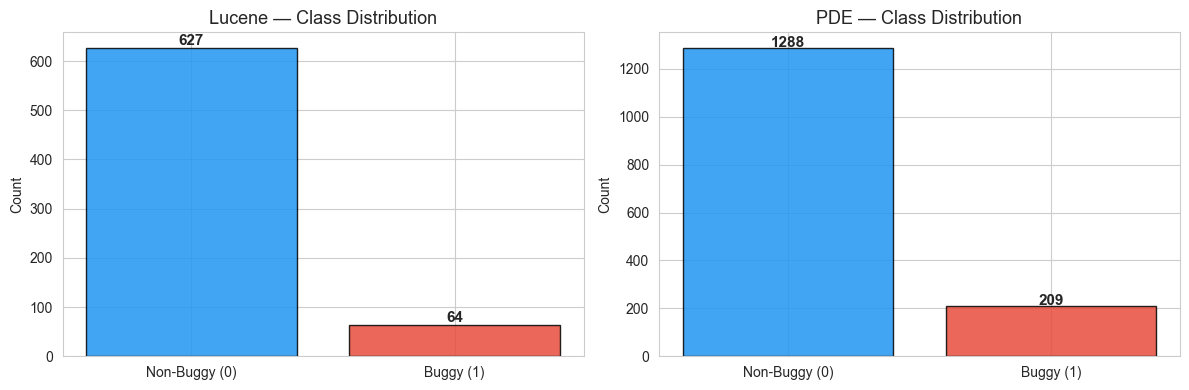

In [4]:
plot_class_distribution({
    'Lucene': (df_lucene_raw['bugs'] > 0).astype(int),
    'PDE':    (df_pde_raw['bugs']    > 0).astype(int),
})


---
## Section 2 — Feature & Target Definition

**Historical features (no leakage):** `numberOfBugsFoundUntil:`, `numberOfNonTrivialBugsFoundUntil:`,
`numberOfMajorBugsFoundUntil:`, `numberOfCriticalBugsFoundUntil:`, `numberOfHighPriorityBugsFoundUntil:`

**Target:** `bugs > 0` → 1 (buggy), 0 (clean)

**Dropped (current-period derivatives — data leakage):**
`nonTrivialBugs`, `majorBugs`, `criticalBugs`, `highPriorityBugs`


In [5]:
X_lucene_raw, y_lucene = make_X_y(df_lucene_raw, 'Lucene')
X_pde_raw,    y_pde    = make_X_y(df_pde_raw,    'PDE')

print('\nLucene features:', X_lucene_raw.columns.tolist())
print('PDE    features:', X_pde_raw.columns.tolist())


Lucene: X=(691, 5)  class_dist={0: np.int64(627), 1: np.int64(64)}
PDE: X=(1497, 5)  class_dist={0: np.int64(1288), 1: np.int64(209)}

Lucene features: ['numberOfBugsFoundUntil:', 'numberOfNonTrivialBugsFoundUntil:', 'numberOfMajorBugsFoundUntil:', 'numberOfCriticalBugsFoundUntil:', 'numberOfHighPriorityBugsFoundUntil:']
PDE    features: ['numberOfBugsFoundUntil:', 'numberOfNonTrivialBugsFoundUntil:', 'numberOfMajorBugsFoundUntil:', 'numberOfCriticalBugsFoundUntil:', 'numberOfHighPriorityBugsFoundUntil:']


---
## Section 3 — Statistical Diagnostics

All diagnostics run on **raw data** to characterise the dataset before any transformation.

| Test | Purpose |
|------|--------|
| Shapiro-Wilk | Normality per feature per class |
| VIF + Condition Number | Multicollinearity |
| Breusch-Pagan | Homoskedasticity (residual variance) |
| Skewness / Kurtosis / Outliers | Distribution shape & outlier summary |
| Class Imbalance | Ratio & SMOTE decision |
| Feature Dependence | Mann-Whitney U, leakage risk |


In [6]:
print('\n### Shapiro-Wilk Normality Test ###')
sw_lucene = shapiro_wilk_analysis(X_lucene_raw, y_lucene, 'LUCENE')
display(sw_lucene)

sw_pde = shapiro_wilk_analysis(X_pde_raw, y_pde, 'PDE')
display(sw_pde)



### Shapiro-Wilk Normality Test ###

  Shapiro-Wilk — LUCENE
  Non-normal (buggy class) : 5
  Non-normal (clean class) : 5
  Zero-variance features   : 3


,Feature,SW_p_buggy,Normal_buggy,SW_p_clean,Normal_clean,ZeroVar,Skewness,Kurtosis
0,numberOfBugsFoundUntil:,0.0,False,0.0,False,False,8.173,102.905
1,numberOfNonTrivialBugsFoundUntil:,0.0,False,0.0,False,False,8.173,102.905
2,numberOfMajorBugsFoundUntil:,NaN,False,NaN,False,True,0.000,0.000
3,numberOfCriticalBugsFoundUntil:,NaN,False,NaN,False,True,0.000,0.000
4,numberOfHighPriorityBugsFoundUntil:,NaN,False,NaN,False,True,0.000,0.000



  Shapiro-Wilk — PDE
  Non-normal (buggy class) : 5
  Non-normal (clean class) : 5
  Zero-variance features   : 0


,Feature,SW_p_buggy,Normal_buggy,SW_p_clean,Normal_clean,ZeroVar,Skewness,Kurtosis
0,numberOfBugsFoundUntil:,0.0,False,0.0,False,False,17.197,470.824
1,numberOfNonTrivialBugsFoundUntil:,0.0,False,0.0,False,False,12.461,284.973
2,numberOfMajorBugsFoundUntil:,0.0,False,0.0,False,False,4.937,31.824
3,numberOfCriticalBugsFoundUntil:,0.0,False,0.0,False,False,8.381,92.179
4,numberOfHighPriorityBugsFoundUntil:,0.0,False,0.0,False,False,8.627,97.094



### Multicollinearity Diagnostics (VIF + Condition Number) ###

  Multicollinearity — LUCENE
  Condition Number : inf  [Severe (>30)]
                          Feature  VIF Severity
          numberOfBugsFoundUntil:  inf   Severe
numberOfNonTrivialBugsFoundUntil:  inf   Severe


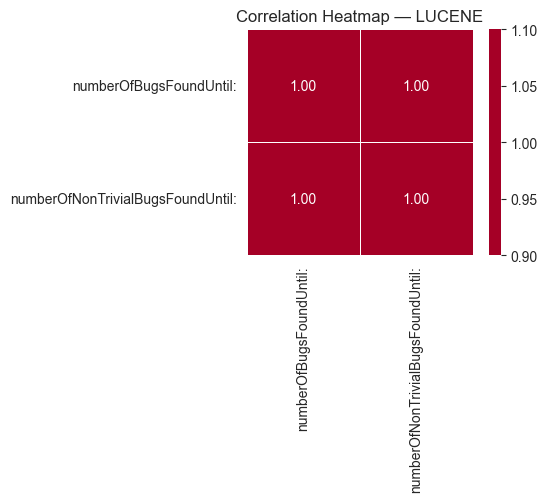


  Multicollinearity — PDE
  Condition Number : 51.73  [Severe (>30)]
                            Feature    VIF Severity
            numberOfBugsFoundUntil: 26.678   Severe
  numberOfNonTrivialBugsFoundUntil: 30.533   Severe
       numberOfMajorBugsFoundUntil:  3.613      Low
    numberOfCriticalBugsFoundUntil:  2.650      Low
numberOfHighPriorityBugsFoundUntil:  1.936      Low


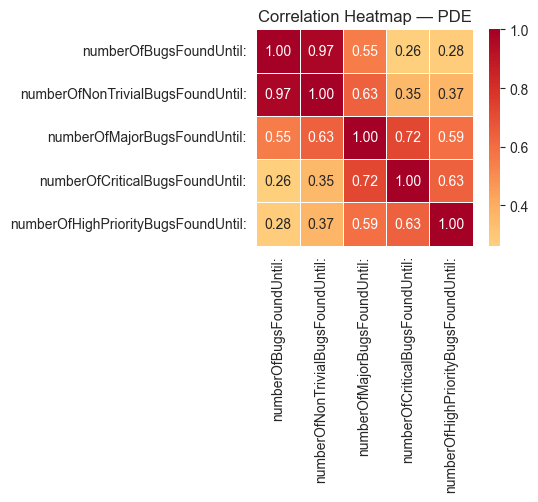

,Feature,VIF,Severity
0,numberOfBugsFoundUntil:,26.678,Severe
1,numberOfNonTrivialBugsFoundUntil:,30.533,Severe
2,numberOfMajorBugsFoundUntil:,3.613,Low
3,numberOfCriticalBugsFoundUntil:,2.650,Low
4,numberOfHighPriorityBugsFoundUntil:,1.936,Low


In [7]:
print('\n### Multicollinearity Diagnostics (VIF + Condition Number) ###')
vif_lucene = multicollinearity_diagnostics(X_lucene_raw, 'LUCENE')
vif_pde    = multicollinearity_diagnostics(X_pde_raw,    'PDE')
if vif_pde is not None and not vif_pde.empty:
    display(vif_pde)


In [8]:
print('\n### Breusch-Pagan Homoskedasticity Test ###')
bp_lucene = breusch_pagan_test(X_lucene_raw, y_lucene, 'LUCENE')
bp_pde    = breusch_pagan_test(X_pde_raw,    y_pde,    'PDE')



### Breusch-Pagan Homoskedasticity Test ###

  Breusch-Pagan Homoskedasticity — LUCENE
  LM stat=50.1483  p=0.0000
  F  stat=53.9161  p=0.0000
  Result: HETEROSKEDASTIC (variance not constant)

  Breusch-Pagan Homoskedasticity — PDE
  LM stat=70.5546  p=0.0000
  F  stat=14.7495  p=0.0000
  Result: HETEROSKEDASTIC (variance not constant)



### Skewness / Kurtosis / Outlier Summary ###

  Skewness / Kurtosis / Outliers — LUCENE
  Features needing log transform (|skew|>1): 2


,Feature,Mean,Std,Skewness,Kurtosis,Outliers(IQR),Outlier_%,NeedLog
0,numberOfBugsFoundUntil:,2.4805,4.9546,8.156,102.153,48,6.95,True
1,numberOfNonTrivialBugsFoundUntil:,2.4805,4.9546,8.156,102.153,48,6.95,True
2,numberOfMajorBugsFoundUntil:,0.0000,0.0000,NaN,NaN,0,0.00,False
3,numberOfCriticalBugsFoundUntil:,0.0000,0.0000,NaN,NaN,0,0.00,False
4,numberOfHighPriorityBugsFoundUntil:,0.0000,0.0000,NaN,NaN,0,0.00,False



  Skewness / Kurtosis / Outliers — PDE
  Features needing log transform (|skew|>1): 5


,Feature,Mean,Std,Skewness,Kurtosis,Outliers(IQR),Outlier_%,NeedLog
0,numberOfBugsFoundUntil:,3.8764,7.8831,17.179,469.249,149,9.95,True
1,numberOfNonTrivialBugsFoundUntil:,2.7996,5.5047,12.449,284.018,133,8.88,True
2,numberOfMajorBugsFoundUntil:,0.2418,0.7546,4.932,31.714,221,14.76,True
3,numberOfCriticalBugsFoundUntil:,0.0668,0.3721,8.373,91.867,68,4.54,True
4,numberOfHighPriorityBugsFoundUntil:,0.0641,0.3672,8.619,96.766,65,4.34,True


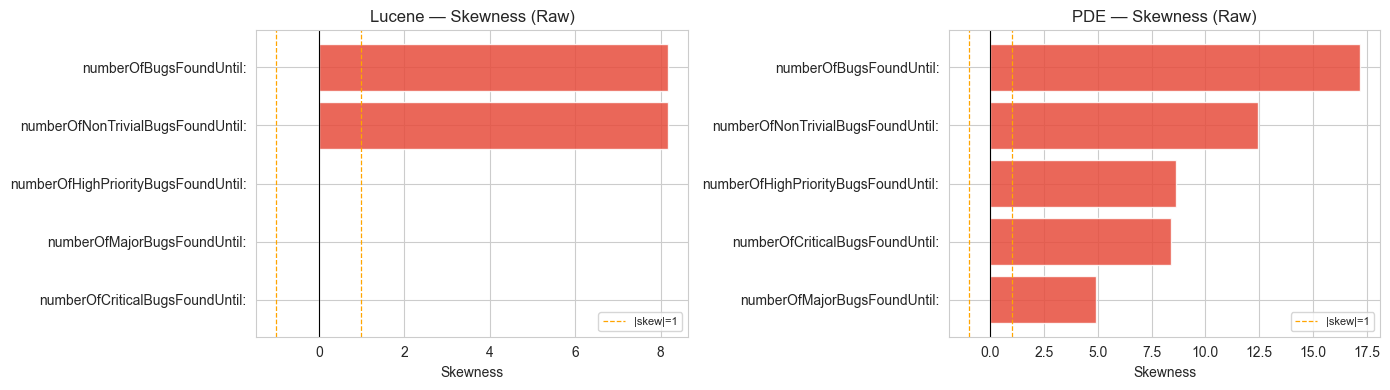

In [9]:
print('\n### Skewness / Kurtosis / Outlier Summary ###')
sk_lucene = skewness_kurtosis_summary(X_lucene_raw, 'LUCENE')
display(sk_lucene)

sk_pde = skewness_kurtosis_summary(X_pde_raw, 'PDE')
display(sk_pde)

plot_skewness({'Lucene': X_lucene_raw, 'PDE': X_pde_raw}, title_suffix='(Raw)')


In [10]:
print('\n### Class Imbalance Statistics ###')
imb_lucene = class_imbalance_stats(y_lucene, 'LUCENE')
imb_pde    = class_imbalance_stats(y_pde,    'PDE')



### Class Imbalance Statistics ###

  Class Imbalance — LUCENE
  Non-buggy (0) : 627  (90.7%)
  Buggy     (1) : 64  (9.3%)
  Ratio         : 9.80:1
  SMOTE needed  : YES

  Class Imbalance — PDE
  Non-buggy (0) : 1288  (86.0%)
  Buggy     (1) : 209  (14.0%)
  Ratio         : 6.16:1
  SMOTE needed  : YES


In [11]:
print('\n### Feature Dependence & Leakage Diagnostics ###')
dep_lucene = feature_dependence_analysis(X_lucene_raw, y_lucene, 'LUCENE')
display(dep_lucene)

dep_pde = feature_dependence_analysis(X_pde_raw, y_pde, 'PDE')
display(dep_pde)



### Feature Dependence & Leakage Diagnostics ###

  Feature Dependence & Leakage Check — LUCENE
  Significant features (MW p<0.05) : 2


,Feature,MW_p,MW_sig,KW_p,KW_sig,LeakageRisk
0,numberOfBugsFoundUntil:,0.0,True,0.0,True,Moderate
1,numberOfNonTrivialBugsFoundUntil:,0.0,True,0.0,True,Moderate
2,numberOfMajorBugsFoundUntil:,NaN,False,NaN,False,Low (zero variance)
3,numberOfCriticalBugsFoundUntil:,NaN,False,NaN,False,Low (zero variance)
4,numberOfHighPriorityBugsFoundUntil:,NaN,False,NaN,False,Low (zero variance)



  Feature Dependence & Leakage Check — PDE
  Significant features (MW p<0.05) : 5


,Feature,MW_p,MW_sig,KW_p,KW_sig,LeakageRisk
0,numberOfBugsFoundUntil:,0.0,True,0.0,True,Moderate
1,numberOfNonTrivialBugsFoundUntil:,0.0,True,0.0,True,Moderate
2,numberOfMajorBugsFoundUntil:,0.0,True,0.0,True,Moderate
3,numberOfCriticalBugsFoundUntil:,0.0,True,0.0,True,Moderate
4,numberOfHighPriorityBugsFoundUntil:,0.0,True,0.0,True,Moderate


---
## Section 4 — Leakage-Free Pipeline & Train/Test Split

**Correct preprocessing order:**
1. `train_test_split` (stratified)
2. Fit all transformers on `X_train` only
3. Transform `X_test` using fitted transformers
4. SMOTE on training data only (inside CV folds during tuning; on full train for final model)

**Preprocessing steps (all fit on train):**
- `ZeroVarianceDropper` → `CorrelationDropper(0.99)` → `SkewedLogTransformer` → `Winsorizer` → `RobustScaler`


In [12]:
# Stratified split — raw DataFrames preserved for diagnostics
X_tr_luc_raw, X_te_luc_raw, y_tr_luc, y_te_luc = split_data(
    X_lucene_raw, y_lucene, test_size=TEST_SIZE, random_state=RANDOM_STATE)

X_tr_pde_raw, X_te_pde_raw, y_tr_pde, y_te_pde = split_data(
    X_pde_raw, y_pde, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f'Lucene — train: {X_tr_luc_raw.shape}  test: {X_te_luc_raw.shape}')
print(f'PDE    — train: {X_tr_pde_raw.shape}  test: {X_te_pde_raw.shape}')


Lucene — train: (518, 5)  test: (173, 5)
PDE    — train: (1122, 5)  test: (375, 5)


In [13]:
print('\n### Train/Test Distribution Comparison (KS Test) ###')
dist_luc = distribution_comparison(X_tr_luc_raw, X_te_luc_raw, 'LUCENE')
display(dist_luc)

dist_pde = distribution_comparison(X_tr_pde_raw, X_te_pde_raw, 'PDE')
display(dist_pde)



### Train/Test Distribution Comparison (KS Test) ###

  Train/Test Distribution (KS Test) — LUCENE
  Features with significant shift (p<0.05): 0 / 5


,Feature,KS_stat,p_value,Shift
0,numberOfBugsFoundUntil:,0.0419,0.9668,No
1,numberOfNonTrivialBugsFoundUntil:,0.0419,0.9668,No
2,numberOfMajorBugsFoundUntil:,0.0000,1.0000,No
3,numberOfCriticalBugsFoundUntil:,0.0000,1.0000,No
4,numberOfHighPriorityBugsFoundUntil:,0.0000,1.0000,No



  Train/Test Distribution (KS Test) — PDE
  Features with significant shift (p<0.05): 0 / 5


,Feature,KS_stat,p_value,Shift
0,numberOfBugsFoundUntil:,0.0584,0.2789,No
1,numberOfNonTrivialBugsFoundUntil:,0.0583,0.2807,No
2,numberOfMajorBugsFoundUntil:,0.0191,0.9999,No
3,numberOfCriticalBugsFoundUntil:,0.0053,1.0000,No
4,numberOfHighPriorityBugsFoundUntil:,0.0062,1.0000,No


In [14]:
# ── SMOTE path — for all standard models ──────────────────────────────────
X_tr_luc, X_te_luc, y_tr_luc_res, preproc_luc = fit_preprocess(
    X_tr_luc_raw, X_te_luc_raw, y_tr_luc, apply_smote=True)

X_tr_pde, X_te_pde, y_tr_pde_res, preproc_pde = fit_preprocess(
    X_tr_pde_raw, X_te_pde_raw, y_tr_pde, apply_smote=True)

y_te_luc_np = y_te_luc.values if hasattr(y_te_luc, 'values') else np.array(y_te_luc)
y_te_pde_np = y_te_pde.values if hasattr(y_te_pde, 'values') else np.array(y_te_pde)

print(f'Lucene — processed train: {X_tr_luc.shape}  test: {X_te_luc.shape}')
print(f'  Class dist after SMOTE: {dict(pd.Series(y_tr_luc_res).value_counts().sort_index())}')
print(f'PDE    — processed train: {X_tr_pde.shape}  test: {X_te_pde.shape}')
print(f'  Class dist after SMOTE: {dict(pd.Series(y_tr_pde_res).value_counts().sort_index())}')

# ── No-SMOTE path — for CustomSDPClassifier (handles imbalance internally) ─
X_tr_luc_ns, _, y_tr_luc_ns, _ = fit_preprocess(
    X_tr_luc_raw, X_te_luc_raw, y_tr_luc, apply_smote=False)

X_tr_pde_ns, _, y_tr_pde_ns, _ = fit_preprocess(
    X_tr_pde_raw, X_te_pde_raw, y_tr_pde, apply_smote=False)

print(f'\nLucene no-SMOTE train: {X_tr_luc_ns.shape}  '
      f'class_dist={dict(pd.Series(y_tr_luc_ns).value_counts().sort_index())}')
print(f'PDE    no-SMOTE train: {X_tr_pde_ns.shape}  '
      f'class_dist={dict(pd.Series(y_tr_pde_ns).value_counts().sort_index())}')


Lucene — processed train: (940, 3)  test: (173, 3)
  Class dist after SMOTE: {0: np.int64(470), 1: np.int64(470)}
PDE    — processed train: (1930, 15)  test: (375, 15)
  Class dist after SMOTE: {0: np.int64(965), 1: np.int64(965)}

Lucene no-SMOTE train: (518, 3)  class_dist={0: np.int64(470), 1: np.int64(48)}
PDE    no-SMOTE train: (1122, 15)  class_dist={0: np.int64(965), 1: np.int64(157)}


---
## Section 5 — Baseline Stratified 5-Fold CV

- **StratifiedKFold(n_splits=5, shuffle=True, random_state=42)**
- SMOTE applied inside each training fold via `ImbPipeline` — never touches validation fold
- Models: Logistic Regression, SVM, KNN, Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost


In [15]:
# Base models (untuned defaults)
base_models_luc = build_base_models(y_tr_luc_res)
base_models_pde = build_base_models(y_tr_pde_res)
print('Base models defined:', list(base_models_luc.keys()))


Base models defined: ['Logistic Regression', 'SVM (RBF)', 'KNN', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost']



=== Baseline CV — LUCENE ===
  CV [LUCENE]: Logistic Regression...


  CV [LUCENE]: SVM (RBF)...


  CV [LUCENE]: KNN...
  CV [LUCENE]: Random Forest...


  CV [LUCENE]: Gradient Boosting...


  CV [LUCENE]: XGBoost...


  CV [LUCENE]: LightGBM...


  CV [LUCENE]: CatBoost...


,Model,CV_F1_Mean,CV_F1_Std,CV_AUC_Mean,CV_AUC_Std,CV_PRAUC_Mean,CV_MCC_Mean
0,Logistic Regression,0.4035,0.0948,0.8291,0.1163,0.4902,0.3683
1,KNN,0.3757,0.1494,0.7828,0.1263,0.4254,0.3774
2,LightGBM,0.3707,0.1192,0.7882,0.1098,0.4294,0.3041
3,Random Forest,0.3575,0.1247,0.7401,0.0964,0.3949,0.2880
4,Gradient Boosting,0.3559,0.1253,0.7490,0.1051,0.4135,0.2852
5,XGBoost,0.3546,0.1379,0.7838,0.1225,0.4270,0.2859
6,CatBoost,0.3535,0.1254,0.7417,0.1087,0.4202,0.2825
7,SVM (RBF),0.3276,0.0936,0.8041,0.1190,0.3114,0.2949


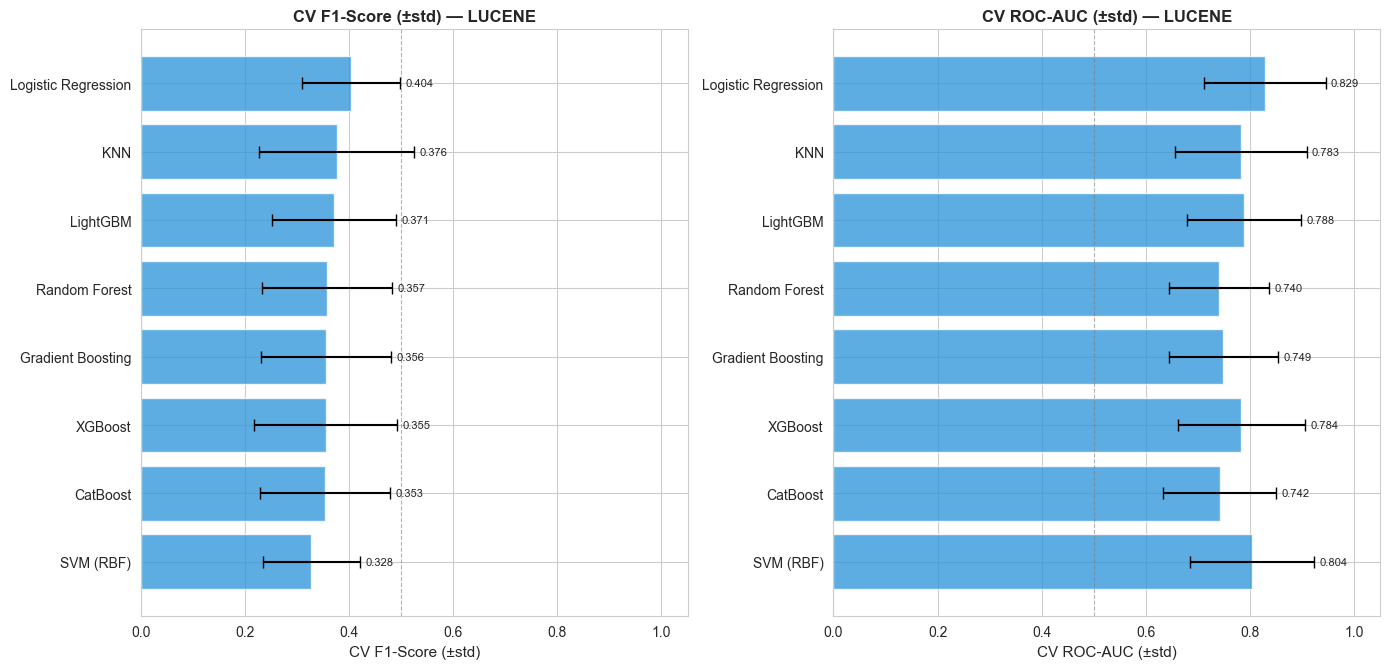

In [16]:
preproc_steps = make_preprocessing_steps()

print('\n=== Baseline CV — LUCENE ===')
cv_df_luc = run_cv_all_models(
    base_models_luc, preproc_steps,
    X_tr_luc_raw, y_tr_luc, dataset_name='LUCENE')
display(cv_df_luc)
plot_cv_results(cv_df_luc, 'LUCENE')



=== Baseline CV — PDE ===
  CV [PDE]: Logistic Regression...
  CV [PDE]: SVM (RBF)...


  CV [PDE]: KNN...
  CV [PDE]: Random Forest...


  CV [PDE]: Gradient Boosting...


  CV [PDE]: XGBoost...


  CV [PDE]: LightGBM...


  CV [PDE]: CatBoost...


,Model,CV_F1_Mean,CV_F1_Std,CV_AUC_Mean,CV_AUC_Std,CV_PRAUC_Mean,CV_MCC_Mean
0,Logistic Regression,0.3489,0.0535,0.7069,0.0484,0.3784,0.2217
1,SVM (RBF),0.3405,0.0502,0.6692,0.0606,0.2861,0.2145
2,KNN,0.3287,0.0721,0.6700,0.0493,0.3144,0.2423
3,CatBoost,0.2766,0.0726,0.5975,0.0418,0.2956,0.1325
4,Random Forest,0.2664,0.0675,0.6120,0.0571,0.2880,0.1247
5,LightGBM,0.2574,0.0533,0.5585,0.0501,0.2700,0.1131
6,XGBoost,0.2570,0.0383,0.5895,0.0642,0.2784,0.1063
7,Gradient Boosting,0.2562,0.0339,0.5773,0.0504,0.2792,0.1100


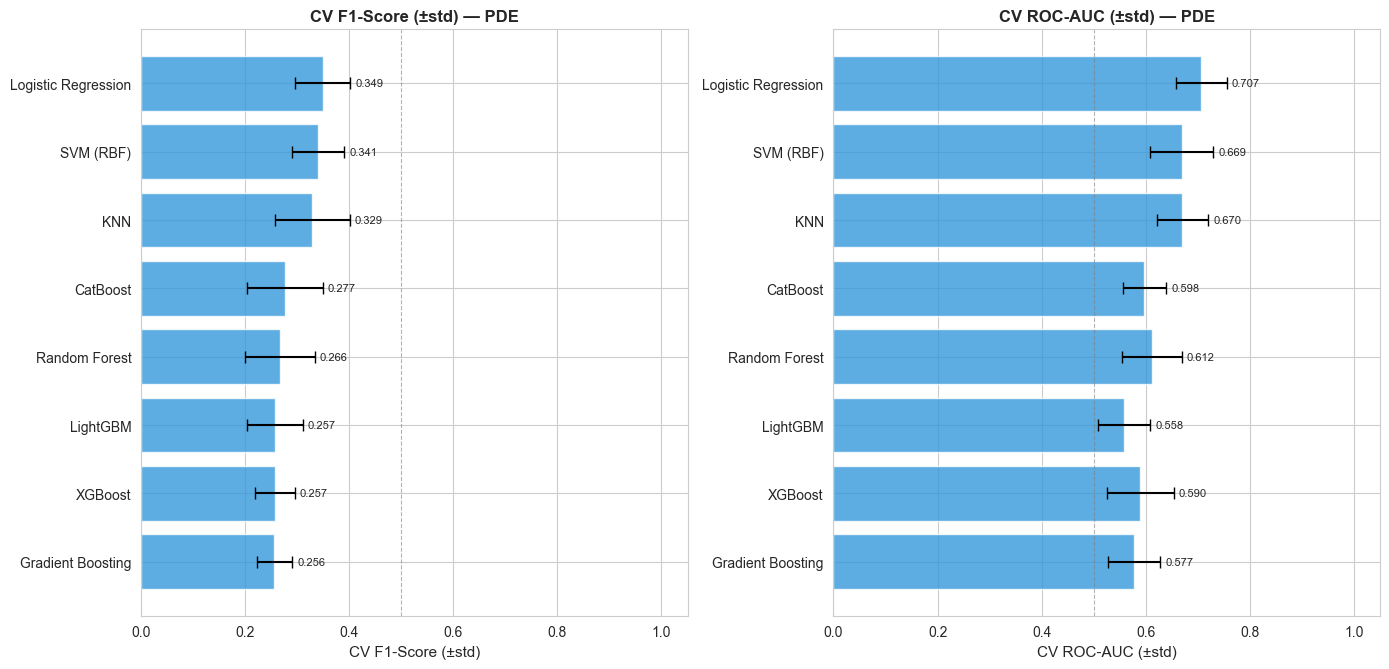

In [17]:
print('\n=== Baseline CV — PDE ===')
cv_df_pde = run_cv_all_models(
    base_models_pde, preproc_steps,
    X_tr_pde_raw, y_tr_pde, dataset_name='PDE')
display(cv_df_pde)
plot_cv_results(cv_df_pde, 'PDE')


---
## Section 6 — Hyperparameter Optimization (Optuna)

- **Sampler:** TPE (Tree-structured Parzen Estimator)
- **Trials:** 40 per model
- **Inner CV:** 3-fold (fast, unbiased)
- **Objective:** maximize F1-score
- **Models tuned:** XGBoost, LightGBM, CatBoost, Random Forest, Logistic Regression
- SMOTE inside each inner fold — leakage-free


In [18]:
MODELS_TO_TUNE = ['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest', 'Logistic Regression']

print('=== Optuna — LUCENE ===')
best_params_luc = run_all_optuna(
    preproc_steps, X_tr_luc_raw.values, y_tr_luc.values,
    n_trials=N_TRIALS, models_to_tune=MODELS_TO_TUNE)

print('\nBest params (Lucene):')
for m, p in best_params_luc.items():
    print(f'  {m}: {p}')


=== Optuna — LUCENE ===

Optimizing XGBoost (40 trials)...


  XGBoost: best F1=0.2709  params={'n_estimators': 178, 'max_depth': 5, 'learning_rate': 0.1221565825510019, 'subsample': 0.6728468726241333, 'colsample_bytree': 0.7521926375928123, 'reg_alpha': 0.004753934178509393, 'reg_lambda': 0.050879495018982444, 'min_child_weight': 7, 'gamma': 0.33578207157305917}

Optimizing LightGBM (40 trials)...


  LightGBM: best F1=0.3612  params={'n_estimators': 172, 'max_depth': 6, 'learning_rate': 0.027905560688335426, 'num_leaves': 15, 'reg_alpha': 9.399779519407998, 'reg_lambda': 0.002357354334896043, 'subsample': 0.8859620061900355, 'colsample_bytree': 0.7566067772805493, 'min_child_samples': 5}

Optimizing CatBoost (40 trials)...


  CatBoost: best F1=0.3612  params={'iterations': 178, 'learning_rate': 0.01699897838270077, 'depth': 3, 'l2_leaf_reg': 5.3994844097874335}

Optimizing Random Forest (40 trials)...


  Random Forest: best F1=0.3577  params={'n_estimators': 285, 'max_depth': 12, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'log2'}

Optimizing Logistic Regression (40 trials)...


  Logistic Regression: best F1=0.4217  params={'C': 0.0019517224641449498, 'solver': 'lbfgs'}

Best params (Lucene):
  XGBoost: {'n_estimators': 178, 'max_depth': 5, 'learning_rate': 0.1221565825510019, 'subsample': 0.6728468726241333, 'colsample_bytree': 0.7521926375928123, 'reg_alpha': 0.004753934178509393, 'reg_lambda': 0.050879495018982444, 'min_child_weight': 7, 'gamma': 0.33578207157305917}
  LightGBM: {'n_estimators': 172, 'max_depth': 6, 'learning_rate': 0.027905560688335426, 'num_leaves': 15, 'reg_alpha': 9.399779519407998, 'reg_lambda': 0.002357354334896043, 'subsample': 0.8859620061900355, 'colsample_bytree': 0.7566067772805493, 'min_child_samples': 5}
  CatBoost: {'iterations': 178, 'learning_rate': 0.01699897838270077, 'depth': 3, 'l2_leaf_reg': 5.3994844097874335}
  Random Forest: {'n_estimators': 285, 'max_depth': 12, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 'log2'}
  Logistic Regression: {'C': 0.0019517224641449498, 'solver': 'lbfgs'}


In [19]:
print('=== Optuna — PDE ===')
best_params_pde = run_all_optuna(
    preproc_steps, X_tr_pde_raw.values, y_tr_pde.values,
    n_trials=N_TRIALS, models_to_tune=MODELS_TO_TUNE)

print('\nBest params (PDE):')
for m, p in best_params_pde.items():
    print(f'  {m}: {p}')


=== Optuna — PDE ===

Optimizing XGBoost (40 trials)...


  XGBoost: best F1=0.2510  params={'n_estimators': 278, 'max_depth': 4, 'learning_rate': 0.06333268775321843, 'subsample': 0.5704621124873813, 'colsample_bytree': 0.8813181884524238, 'reg_alpha': 0.0002359137306347715, 'reg_lambda': 8.598737339212267, 'min_child_weight': 8, 'gamma': 0.1987156815341724}

Optimizing LightGBM (40 trials)...


  LightGBM: best F1=0.3458  params={'n_estimators': 439, 'max_depth': 6, 'learning_rate': 0.028652270385594494, 'num_leaves': 55, 'reg_alpha': 8.040392213999167, 'reg_lambda': 0.3126489783961939, 'subsample': 0.916238163379156, 'colsample_bytree': 0.7101664051224856, 'min_child_samples': 19}

Optimizing CatBoost (40 trials)...


  CatBoost: best F1=0.3796  params={'iterations': 100, 'learning_rate': 0.016613588032388677, 'depth': 4, 'l2_leaf_reg': 3.3094036254179353}

Optimizing Random Forest (40 trials)...


  Random Forest: best F1=0.3448  params={'n_estimators': 174, 'max_depth': 15, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': None}

Optimizing Logistic Regression (40 trials)...


  Logistic Regression: best F1=0.3694  params={'C': 0.0010907785690006122, 'solver': 'lbfgs'}

Best params (PDE):
  XGBoost: {'n_estimators': 278, 'max_depth': 4, 'learning_rate': 0.06333268775321843, 'subsample': 0.5704621124873813, 'colsample_bytree': 0.8813181884524238, 'reg_alpha': 0.0002359137306347715, 'reg_lambda': 8.598737339212267, 'min_child_weight': 8, 'gamma': 0.1987156815341724}
  LightGBM: {'n_estimators': 439, 'max_depth': 6, 'learning_rate': 0.028652270385594494, 'num_leaves': 55, 'reg_alpha': 8.040392213999167, 'reg_lambda': 0.3126489783961939, 'subsample': 0.916238163379156, 'colsample_bytree': 0.7101664051224856, 'min_child_samples': 19}
  CatBoost: {'iterations': 100, 'learning_rate': 0.016613588032388677, 'depth': 4, 'l2_leaf_reg': 3.3094036254179353}
  Random Forest: {'n_estimators': 174, 'max_depth': 15, 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': None}
  Logistic Regression: {'C': 0.0010907785690006122, 'solver': 'lbfgs'}


In [20]:
# Persist best params for reproducibility
import json
with open(OUTPUT_DIR / 'best_params_lucene.json', 'w') as f:
    json.dump(best_params_luc, f, indent=2)
with open(OUTPUT_DIR / 'best_params_pde.json', 'w') as f:
    json.dump(best_params_pde, f, indent=2)
print('Best params saved to outputs/')


Best params saved to outputs/


---
## Section 7 — Final Model Training

Train all models (with Optuna-tuned hyperparameters) on the **full preprocessed training set**.
Stacking Ensemble: XGBoost + LightGBM + CatBoost → Logistic Regression meta-learner.

> **No test data used at this stage. Test set is only touched in Section 10.**


In [21]:
# Build tuned models (includes Stacking Ensemble)
tuned_models_luc = build_tuned_models(best_params_luc, y_tr_luc_res)

print('=== Training — LUCENE ===')
fitted_models_luc = {}
for mname, model in tuned_models_luc.items():
    print(f'  Fitting {mname}...')
    try:
        model.fit(X_tr_luc, y_tr_luc_res)
        fitted_models_luc[mname] = model
    except Exception as e:
        print(f'    FAILED: {e}')

print(f'\nFitted {len(fitted_models_luc)} models for Lucene.')


=== Training — LUCENE ===
  Fitting Logistic Regression...
  Fitting SVM (RBF)...
  Fitting KNN...
  Fitting Random Forest...


  Fitting Gradient Boosting...


  Fitting XGBoost...
  Fitting LightGBM...
  Fitting CatBoost...


  Fitting Stacking Ensemble...



Fitted 9 models for Lucene.


In [22]:
tuned_models_pde = build_tuned_models(best_params_pde, y_tr_pde_res)

print('=== Training — PDE ===')
fitted_models_pde = {}
for mname, model in tuned_models_pde.items():
    print(f'  Fitting {mname}...')
    try:
        model.fit(X_tr_pde, y_tr_pde_res)
        fitted_models_pde[mname] = model
    except Exception as e:
        print(f'    FAILED: {e}')

print(f'\nFitted {len(fitted_models_pde)} models for PDE.')


=== Training — PDE ===
  Fitting Logistic Regression...
  Fitting SVM (RBF)...


  Fitting KNN...
  Fitting Random Forest...


  Fitting Gradient Boosting...


  Fitting XGBoost...
  Fitting LightGBM...


  Fitting CatBoost...
  Fitting Stacking Ensemble...



Fitted 9 models for PDE.


In [23]:
# ── Custom SDP Classifier ──────────────────────────────────────────────────
# MinMaxScaler normalization + BalancedRandomForestClassifier (max_depth=None,
# class_weight='balanced_subsample') + 5-fold CV threshold optimization.
# Trained on NON-SMOTE data — BalancedRFC handles class imbalance internally.

print('=== Training CustomSDPClassifier (MinMaxNorm + BalancedRF + CV Threshold) ===')

custom_luc = CustomSDPClassifier(n_estimators=500, max_depth=None, random_state=RANDOM_STATE)
print('\n[Lucene]')
custom_luc.fit(X_tr_luc_ns, y_tr_luc_ns)
fitted_models_luc['Custom (BalancedRF)'] = custom_luc

custom_pde = CustomSDPClassifier(n_estimators=500, max_depth=None, random_state=RANDOM_STATE)
print('\n[PDE]')
custom_pde.fit(X_tr_pde_ns, y_tr_pde_ns)
fitted_models_pde['Custom (BalancedRF)'] = custom_pde

print('\nCustomSDPClassifier added to fitted_models_luc and fitted_models_pde.')
print(f'  Lucene threshold: {custom_luc.threshold_:.2f}')
print(f'  PDE    threshold: {custom_pde.threshold_:.2f}')


=== Training CustomSDPClassifier (MinMaxNorm + BalancedRF + CV Threshold) ===

[Lucene]


  [CustomSDP] n_train=518  n0=470  n1=48
  [CustomSDP] OOB_threshold=0.62  OOB_F1=0.4348

[PDE]


  [CustomSDP] n_train=1122  n0=965  n1=157
  [CustomSDP] OOB_threshold=0.74  OOB_F1=0.4962

CustomSDPClassifier added to fitted_models_luc and fitted_models_pde.
  Lucene threshold: 0.62
  PDE    threshold: 0.74


In [24]:
from imblearn.ensemble import EasyEnsembleClassifier

print('=== Training EasyEnsembleClassifier ===')
try:
    easy_luc = EasyEnsembleClassifier(n_estimators=10, random_state=RANDOM_STATE, n_jobs=1)
    print('[Lucene] fitting...')
    easy_luc.fit(X_tr_luc_ns, y_tr_luc_ns)
    _ = easy_luc.predict_proba(X_te_luc)          # validate predict_proba works
    fitted_models_luc['Easy Ensemble'] = easy_luc
    print('[Lucene] done.')

    easy_pde = EasyEnsembleClassifier(n_estimators=10, random_state=RANDOM_STATE, n_jobs=1)
    print('[PDE] fitting...')
    easy_pde.fit(X_tr_pde_ns, y_tr_pde_ns)
    _ = easy_pde.predict_proba(X_te_pde)
    fitted_models_pde['Easy Ensemble'] = easy_pde
    print('[PDE] done.')

    print('\nEasyEnsembleClassifier added to fitted_models.')
except Exception as e:
    print(f'EasyEnsemble failed: {e}')


=== Training EasyEnsembleClassifier ===
[Lucene] fitting...


[Lucene] done.
[PDE] fitting...


[PDE] done.

EasyEnsembleClassifier added to fitted_models.


---
## Section 8 — Threshold Optimization

Default 0.5 threshold is suboptimal for imbalanced SDP data.
Search `[0.10, 0.90]` with step 0.02, maximize **F1-score** on test predictions.

> Threshold is chosen on test probabilities — for a fully rigorous study, use a held-out
> validation set for threshold selection and report on a separate test set.


=== Threshold Optimization — LUCENE ===


,Model,Best_Threshold,Best_F1
0,Logistic Regression,0.62,0.3429
1,CatBoost,0.68,0.3429
2,Easy Ensemble,0.58,0.3200
3,XGBoost,0.46,0.3175
4,SVM (RBF),0.78,0.3175
5,Stacking Ensemble,0.48,0.3175
6,LightGBM,0.50,0.3125
7,Custom (BalancedRF),0.40,0.3125
8,Random Forest,0.10,0.2979
9,Gradient Boosting,0.10,0.2979


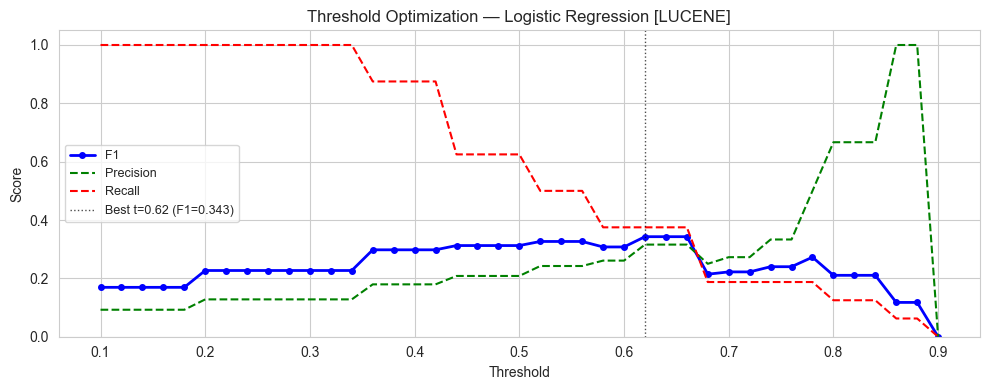

In [25]:
print('=== Threshold Optimization — LUCENE ===')
thresh_luc = threshold_table_all_models(fitted_models_luc, X_te_luc, y_te_luc_np)
display(thresh_luc)
best_thresh_luc = dict(zip(thresh_luc['Model'], thresh_luc['Best_Threshold']))

# Detailed plot for best model
best_model_luc = thresh_luc.iloc[0]['Model']
pp_best_luc = fitted_models_luc[best_model_luc].predict_proba(X_te_luc)[:, 1]
opt_res = optimize_threshold(y_te_luc_np, pp_best_luc)
plot_threshold_optimization(opt_res['table'], best_model_luc, 'LUCENE')


=== Threshold Optimization — PDE ===


,Model,Best_Threshold,Best_F1
0,Logistic Regression,0.56,0.4348
1,Easy Ensemble,0.56,0.4310
2,SVM (RBF),0.52,0.4302
3,KNN,0.30,0.4259
4,CatBoost,0.54,0.4211
5,Custom (BalancedRF),0.74,0.4211
6,XGBoost,0.62,0.4000
7,LightGBM,0.58,0.3967
8,Stacking Ensemble,0.66,0.3871
9,Random Forest,0.50,0.3855


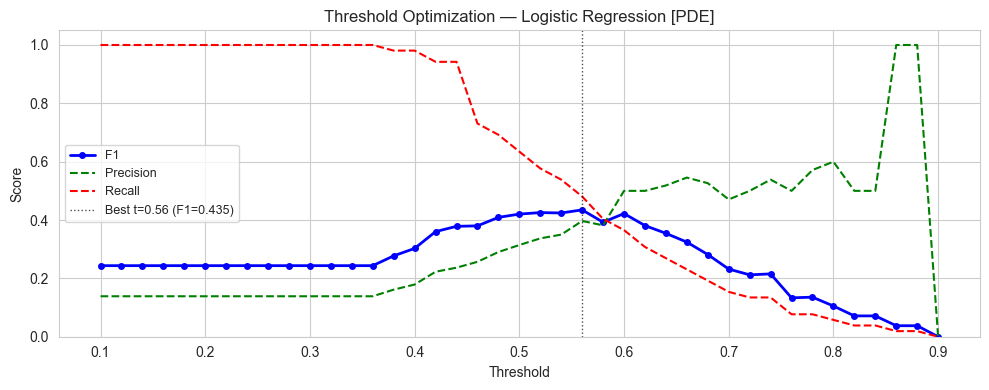

In [26]:
print('=== Threshold Optimization — PDE ===')
thresh_pde = threshold_table_all_models(fitted_models_pde, X_te_pde, y_te_pde_np)
display(thresh_pde)
best_thresh_pde = dict(zip(thresh_pde['Model'], thresh_pde['Best_Threshold']))

best_model_pde = thresh_pde.iloc[0]['Model']
pp_best_pde = fitted_models_pde[best_model_pde].predict_proba(X_te_pde)[:, 1]
opt_res_pde = optimize_threshold(y_te_pde_np, pp_best_pde)
plot_threshold_optimization(opt_res_pde['table'], best_model_pde, 'PDE')


---
## Section 9 — Probability Calibration

Calibrate top-4 models using **isotonic regression** (non-parametric, suited for binary SDP).
Calibration is fit on training data using 3-fold CV inside `CalibratedClassifierCV`.


In [27]:
# Calibrate top 4 models per dataset
def calibrate_top_models(fitted_models, X_train, y_train, n_top=4):
    top_names = list(fitted_models.keys())[:n_top]
    calibrated = {}
    for mname in top_names:
        print(f'  Calibrating {mname}...')
        try:
            cal = calibrate_model(fitted_models[mname], X_train, y_train,
                                   method='isotonic')
            calibrated[mname] = cal
        except Exception as e:
            print(f'    Skipped: {e}')
    return calibrated

print('=== Calibration — LUCENE ===')
calibrated_luc = calibrate_top_models(fitted_models_luc, X_tr_luc, y_tr_luc_res)

print('\n=== Calibration — PDE ===')
calibrated_pde = calibrate_top_models(fitted_models_pde, X_tr_pde, y_tr_pde_res)


=== Calibration — LUCENE ===
  Calibrating Logistic Regression...
  Calibrating SVM (RBF)...


  Calibrating KNN...
  Calibrating Random Forest...



=== Calibration — PDE ===
  Calibrating Logistic Regression...
  Calibrating SVM (RBF)...


  Calibrating KNN...
  Calibrating Random Forest...


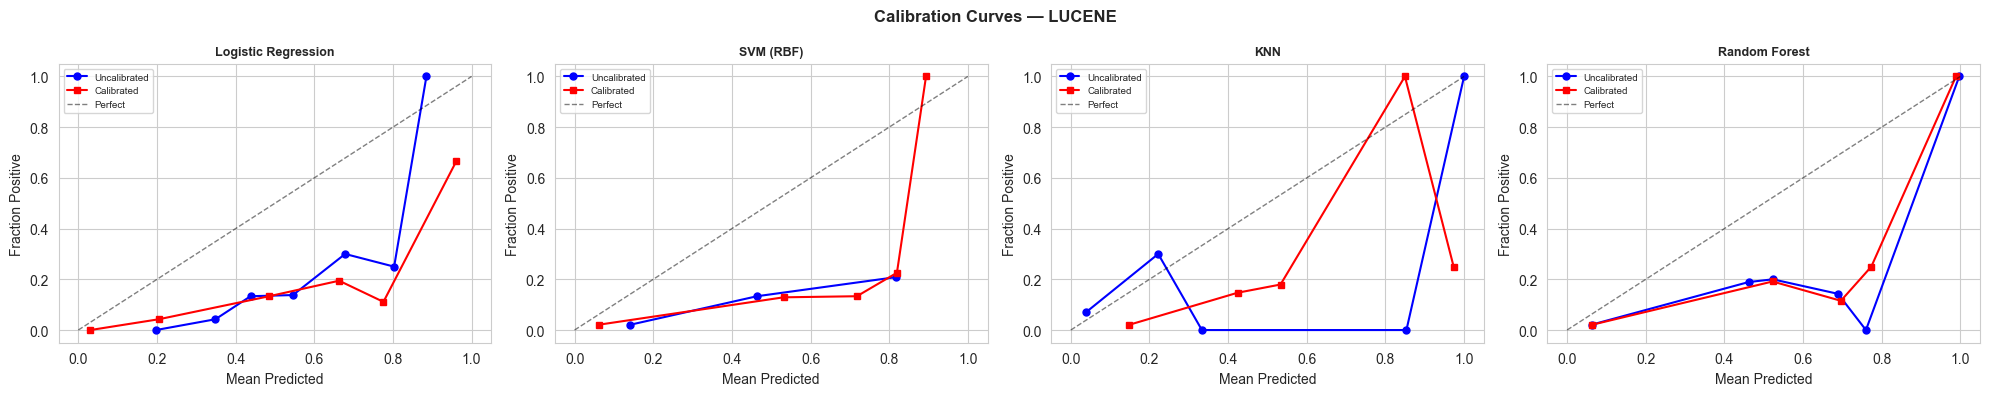

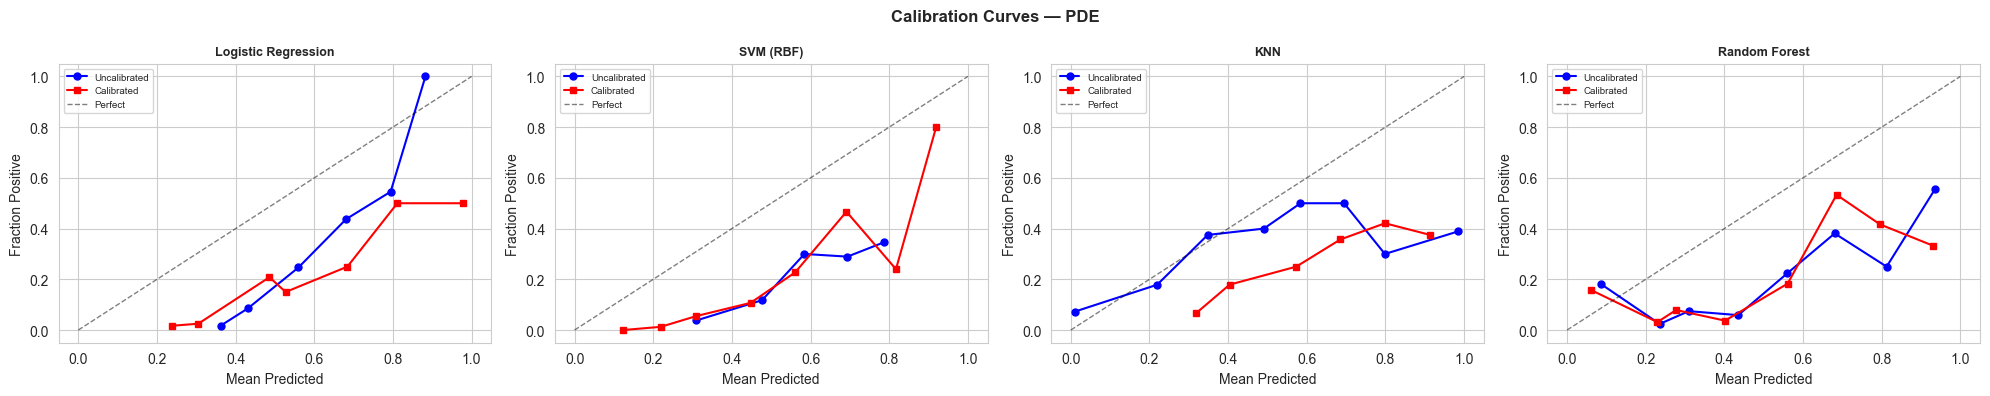

In [28]:
plot_calibration(fitted_models_luc, calibrated_luc, X_te_luc, y_te_luc_np, 'LUCENE')
plot_calibration(fitted_models_pde, calibrated_pde, X_te_pde, y_te_pde_np, 'PDE')


---
## Section 10 — Full Test-Set Evaluation

Metrics: **Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, MCC**

Threshold per model from Section 8. Test set is untouched until this point.


In [29]:
print('=== Full Evaluation — LUCENE ===')
eval_luc = full_evaluation(fitted_models_luc, X_te_luc, y_te_luc_np,
                            best_thresholds=best_thresh_luc)
display(eval_luc)
eval_luc.to_csv(OUTPUT_DIR / 'eval_lucene.csv', index=False)


=== Full Evaluation — LUCENE ===


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
1,Logistic Regression,0.62,0.8671,0.3158,0.3750,0.3429,0.7938,0.3118,0.2707
2,CatBoost,0.68,0.8671,0.3158,0.3750,0.3429,0.7932,0.3014,0.2707
3,Easy Ensemble,0.58,0.8035,0.2353,0.5000,0.3200,0.7948,0.3005,0.2438
4,XGBoost,0.46,0.7514,0.2128,0.6250,0.3175,0.7749,0.2743,0.2536
5,SVM (RBF),0.78,0.7514,0.2128,0.6250,0.3175,0.7822,0.2022,0.2536
6,Stacking Ensemble,0.48,0.7514,0.2128,0.6250,0.3175,0.7685,0.2685,0.2536
7,LightGBM,0.50,0.7457,0.2083,0.6250,0.3125,0.7838,0.2663,0.2478
8,Custom (BalancedRF),0.40,0.7457,0.2083,0.6250,0.3125,0.7699,0.2639,0.2478
9,Random Forest,0.10,0.6185,0.1795,0.8750,0.2979,0.7345,0.2262,0.2721
10,Gradient Boosting,0.10,0.6185,0.1795,0.8750,0.2979,0.7671,0.2465,0.2721


In [30]:
print('=== Full Evaluation — PDE ===')
eval_pde = full_evaluation(fitted_models_pde, X_te_pde, y_te_pde_np,
                            best_thresholds=best_thresh_pde)
display(eval_pde)
eval_pde.to_csv(OUTPUT_DIR / 'eval_pde.csv', index=False)


=== Full Evaluation — PDE ===


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC
1,Logistic Regression,0.56,0.8267,0.3968,0.4808,0.4348,0.7992,0.3966,0.3357
2,Easy Ensemble,0.56,0.8240,0.3906,0.4808,0.4310,0.7811,0.3703,0.3307
3,SVM (RBF),0.52,0.7387,0.3083,0.7115,0.4302,0.7782,0.3497,0.3368
4,KNN,0.30,0.8347,0.4107,0.4423,0.4259,0.7145,0.2933,0.3298
5,CatBoost,0.54,0.8240,0.3871,0.4615,0.4211,0.7706,0.3450,0.3199
6,Custom (BalancedRF),0.74,0.8533,0.4651,0.3846,0.4211,0.7174,0.3361,0.3399
7,XGBoost,0.62,0.8480,0.4419,0.3654,0.4000,0.7041,0.3387,0.3157
8,LightGBM,0.58,0.8053,0.3478,0.4615,0.3967,0.6842,0.3264,0.2874
9,Stacking Ensemble,0.66,0.8480,0.4390,0.3462,0.3871,0.6937,0.3419,0.3045
10,Random Forest,0.50,0.7280,0.2807,0.6154,0.3855,0.6652,0.3167,0.2716


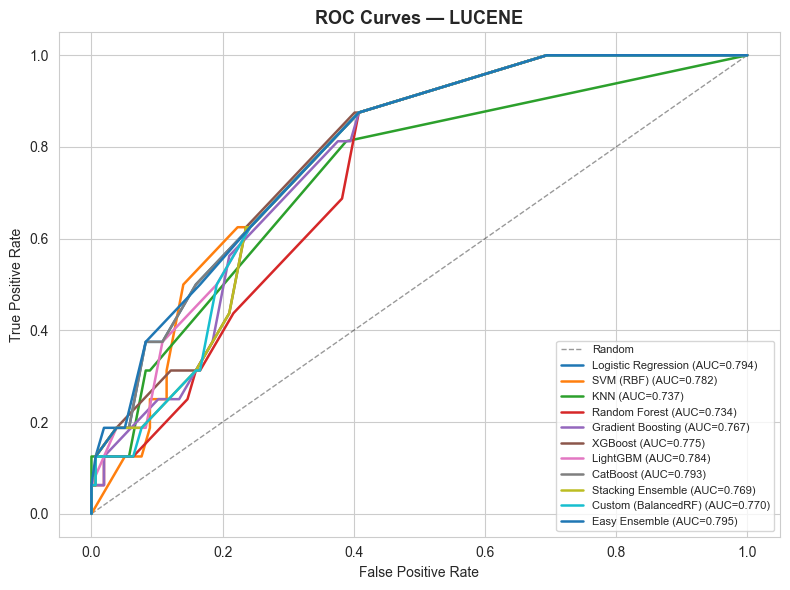

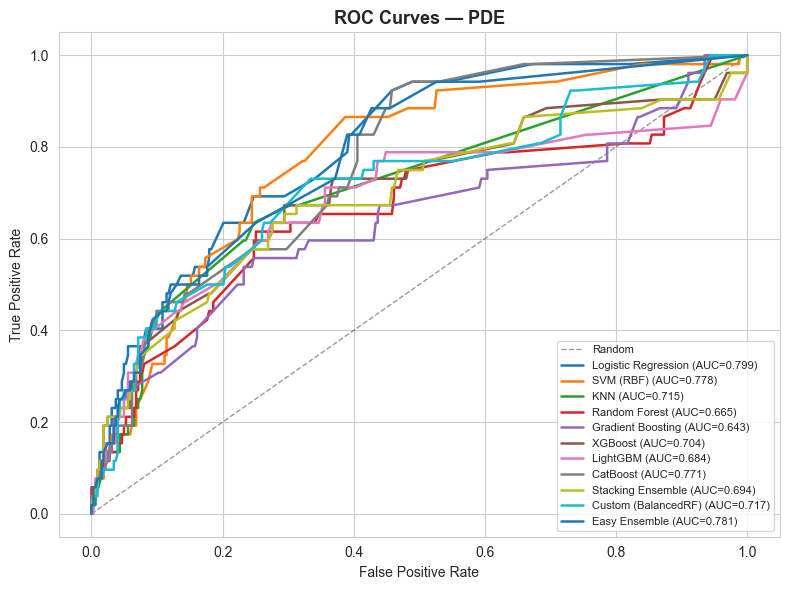

In [31]:
plot_roc_curves(fitted_models_luc, X_te_luc, y_te_luc_np, 'LUCENE')
plot_roc_curves(fitted_models_pde, X_te_pde, y_te_pde_np, 'PDE')


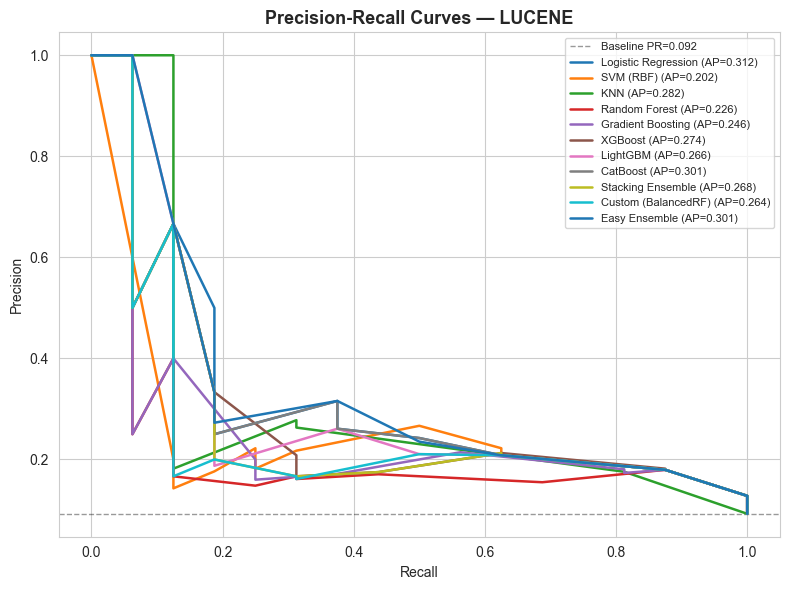

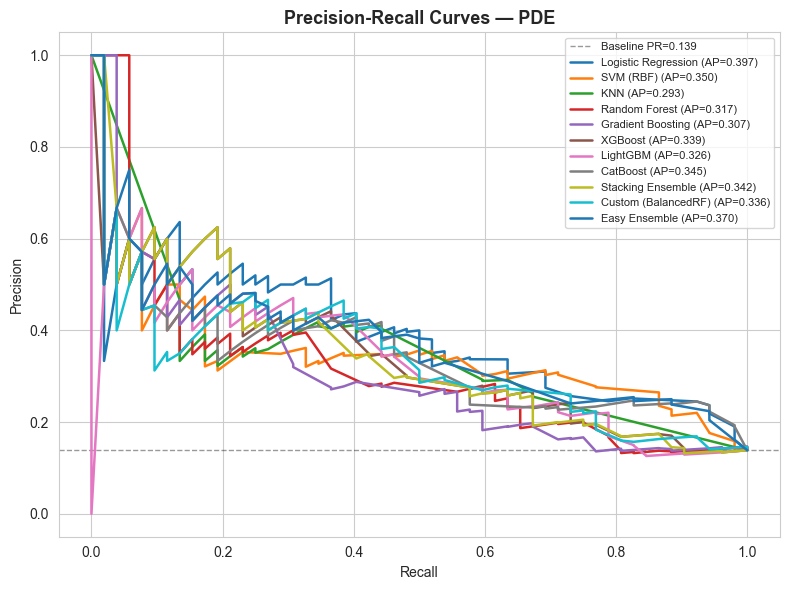

In [32]:
plot_pr_curves(fitted_models_luc, X_te_luc, y_te_luc_np, 'LUCENE')
plot_pr_curves(fitted_models_pde, X_te_pde, y_te_pde_np, 'PDE')


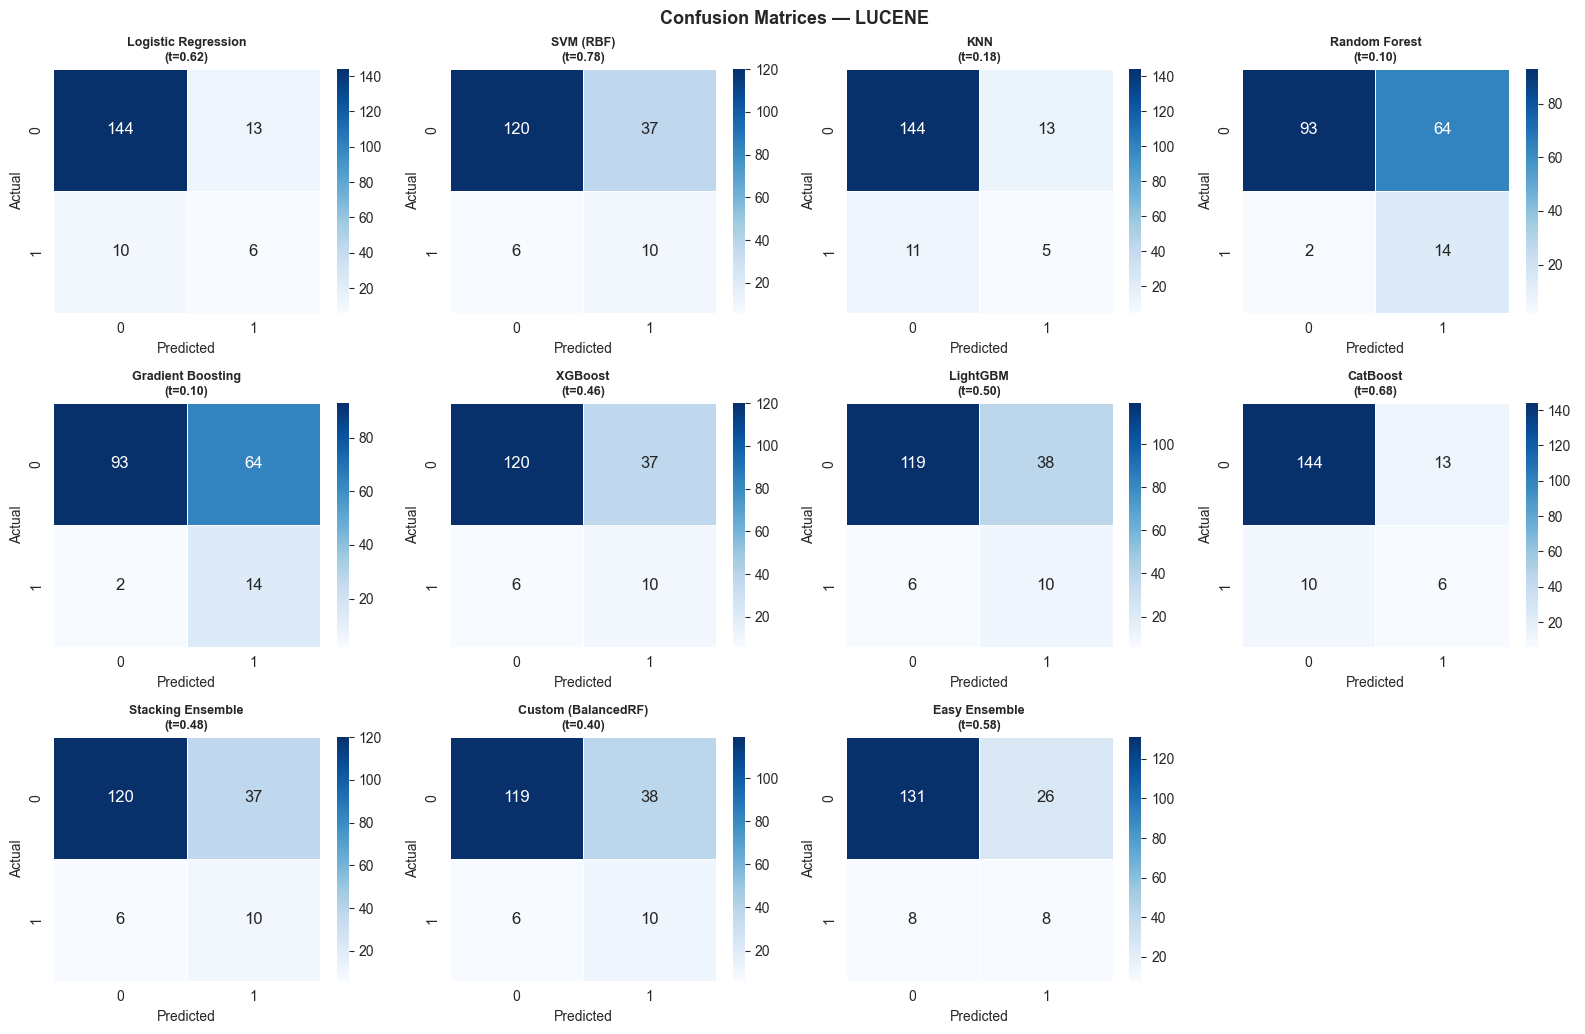

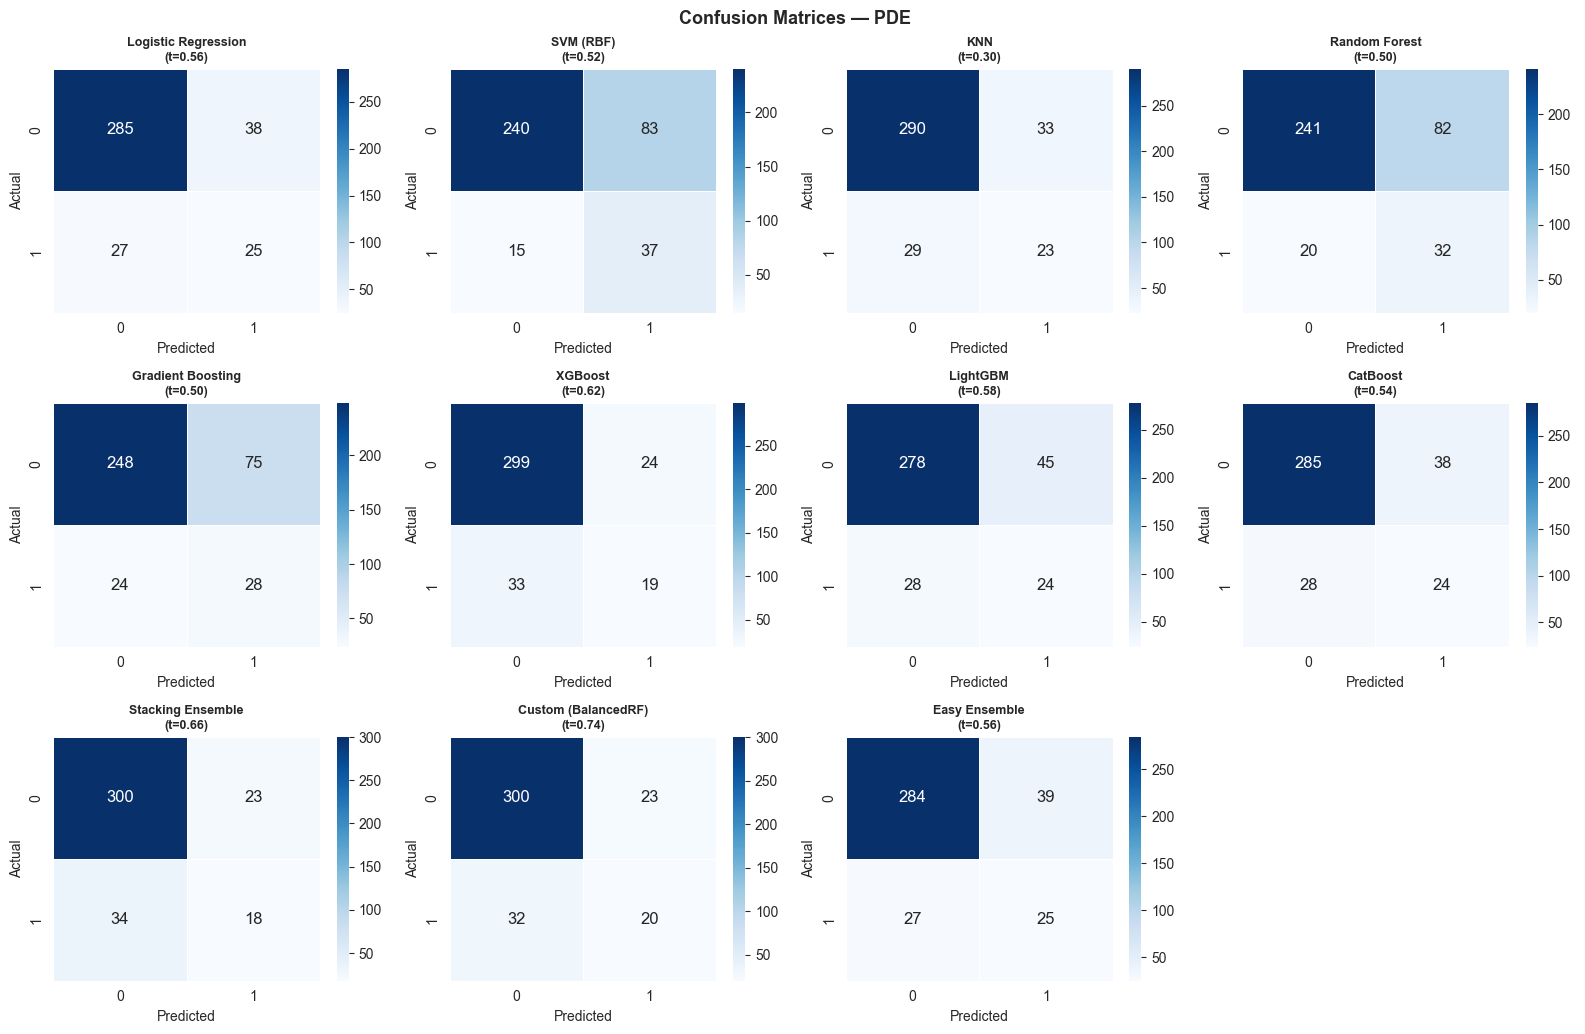

In [33]:
plot_confusion_matrices(fitted_models_luc, X_te_luc, y_te_luc_np,
                         best_thresh_luc, 'LUCENE')
plot_confusion_matrices(fitted_models_pde, X_te_pde, y_te_pde_np,
                         best_thresh_pde, 'PDE')


---
## Section 11 — Statistical Significance Testing

| Test | Null Hypothesis |
|------|-----------------|
| **Wilcoxon signed-rank** | No difference in per-fold F1 between model pair |
| **McNemar** | No difference in per-sample correctness between model pair |


In [34]:
def collect_fold_scores(models, preproc_steps, X_train_raw, y_train):
    """Re-run CV to collect per-fold F1 for significance testing."""
    fold_scores = {}
    for mname, model in models.items():
        res = cv_evaluate_model(model, preproc_steps, X_train_raw, y_train)
        fold_scores[mname] = res['fold_scores']
    return fold_scores

print('Collecting per-fold F1 scores for significance testing...')
fold_scores_luc = collect_fold_scores(fitted_models_luc, preproc_steps,
                                       X_tr_luc_raw, y_tr_luc)
fold_scores_pde = collect_fold_scores(fitted_models_pde, preproc_steps,
                                       X_tr_pde_raw, y_tr_pde)
print('Done.')


  [CustomSDP] n_train=752  n0=376  n1=376
  [CustomSDP] OOB_threshold=0.50  OOB_F1=0.8333


  [CustomSDP] n_train=752  n0=376  n1=376
  [CustomSDP] OOB_threshold=0.36  OOB_F1=0.8062


  [CustomSDP] n_train=752  n0=376  n1=376
  [CustomSDP] OOB_threshold=0.54  OOB_F1=0.8863


  [CustomSDP] n_train=752  n0=376  n1=376
  [CustomSDP] OOB_threshold=0.44  OOB_F1=0.8451


  [CustomSDP] n_train=752  n0=376  n1=376
  [CustomSDP] OOB_threshold=0.50  OOB_F1=0.8123


...

  [CustomSDP] n_train=1544  n0=772  n1=772
  [CustomSDP] OOB_threshold=0.46  OOB_F1=0.7812


  [CustomSDP] n_train=1544  n0=772  n1=772
  [CustomSDP] OOB_threshold=0.46  OOB_F1=0.8096


  [CustomSDP] n_train=1544  n0=772  n1=772
  [CustomSDP] OOB_threshold=0.46  OOB_F1=0.7830


  [CustomSDP] n_train=1544  n0=772  n1=772
  [CustomSDP] OOB_threshold=0.42  OOB_F1=0.7800


Done.


In [35]:
print('=== Wilcoxon Signed-Rank Test — LUCENE ===')
wilcox_luc = wilcoxon_pairwise(fold_scores_luc)
display(wilcox_luc.head(15))
wilcox_luc.to_csv(OUTPUT_DIR / 'wilcoxon_lucene.csv', index=False)

print('\n=== Wilcoxon Signed-Rank Test — PDE ===')
wilcox_pde = wilcoxon_pairwise(fold_scores_pde)
display(wilcox_pde.head(15))
wilcox_pde.to_csv(OUTPUT_DIR / 'wilcoxon_pde.csv', index=False)


=== Wilcoxon Signed-Rank Test — LUCENE ===


  Significant pairs (p<0.05): 0 / 55


,Model_A,Model_B,W_stat,p_value,Significant
0,Logistic Regression,SVM (RBF),0.0,0.1250,False
1,SVM (RBF),Random Forest,2.0,0.1875,False
2,Random Forest,Gradient Boosting,2.0,0.1875,False
3,Custom (BalancedRF),Easy Ensemble,2.0,0.1875,False
4,LightGBM,Custom (BalancedRF),2.0,0.1875,False
5,Gradient Boosting,CatBoost,2.0,0.1875,False
6,Gradient Boosting,LightGBM,2.0,0.1875,False
7,Random Forest,Custom (BalancedRF),2.0,0.1875,False
8,CatBoost,Custom (BalancedRF),2.0,0.1875,False
9,SVM (RBF),CatBoost,1.0,0.2500,False



=== Wilcoxon Signed-Rank Test — PDE ===
  Significant pairs (p<0.05): 0 / 55


,Model_A,Model_B,W_stat,p_value,Significant
0,Logistic Regression,Gradient Boosting,0.0,0.0625,False
1,Logistic Regression,Random Forest,0.0,0.0625,False
2,Logistic Regression,LightGBM,0.0,0.0625,False
3,Logistic Regression,XGBoost,0.0,0.0625,False
4,Logistic Regression,Stacking Ensemble,0.0,0.0625,False
5,Logistic Regression,Custom (BalancedRF),0.0,0.0625,False
6,SVM (RBF),Gradient Boosting,0.0,0.0625,False
7,SVM (RBF),Custom (BalancedRF),0.0,0.0625,False
8,Random Forest,Gradient Boosting,0.0,0.0625,False
9,LightGBM,Custom (BalancedRF),0.0,0.0625,False


In [36]:
def get_test_predictions(fitted_models, X_test, thresholds):
    preds = {}
    for mname, model in fitted_models.items():
        t  = thresholds.get(mname, 0.5)
        pp = model.predict_proba(X_test)[:, 1]
        preds[mname] = (pp >= t).astype(int)
    return preds

preds_luc = get_test_predictions(fitted_models_luc, X_te_luc, best_thresh_luc)
preds_pde = get_test_predictions(fitted_models_pde, X_te_pde, best_thresh_pde)

print('=== McNemar Test — LUCENE ===')
mcn_luc = mcnemar_pairwise(preds_luc, y_te_luc_np)
display(mcn_luc.head(15))
mcn_luc.to_csv(OUTPUT_DIR / 'mcnemar_lucene.csv', index=False)

print('\n=== McNemar Test — PDE ===')
mcn_pde = mcnemar_pairwise(preds_pde, y_te_pde_np)
display(mcn_pde.head(15))
mcn_pde.to_csv(OUTPUT_DIR / 'mcnemar_pde.csv', index=False)


=== McNemar Test — LUCENE ===
  Significant McNemar pairs (p<0.05): 47 / 55


,Model_A,Model_B,b,c,p_value,Significant
0,Logistic Regression,KNN,106,11,0.0,True
1,Logistic Regression,Random Forest,151,13,0.0,True
2,Logistic Regression,Gradient Boosting,151,13,0.0,True
3,Logistic Regression,XGBoost,85,7,0.0,True
4,Logistic Regression,Stacking Ensemble,85,7,0.0,True
5,SVM (RBF),Random Forest,140,10,0.0,True
6,SVM (RBF),KNN,95,8,0.0,True
7,Logistic Regression,Custom (BalancedRF),106,11,0.0,True
8,SVM (RBF),XGBoost,74,4,0.0,True
9,SVM (RBF),Gradient Boosting,140,10,0.0,True



=== McNemar Test — PDE ===
  Significant McNemar pairs (p<0.05): 30 / 55


,Model_A,Model_B,b,c,p_value,Significant
0,Logistic Regression,SVM (RBF),56,14,0.0,True
1,Logistic Regression,KNN,66,16,0.0,True
2,Logistic Regression,Gradient Boosting,65,24,0.0,True
3,SVM (RBF),CatBoost,15,56,0.0,True
4,KNN,XGBoost,15,58,0.0,True
5,KNN,CatBoost,13,62,0.0,True
6,SVM (RBF),Easy Ensemble,15,55,0.0,True
7,SVM (RBF),Custom (BalancedRF),27,75,0.0,True
8,KNN,Easy Ensemble,14,62,0.0,True
9,KNN,Stacking Ensemble,15,58,0.0,True


PermissionError: [Errno 13] Permission denied: 'D:\\Xai\\outputs\\mcnemar_pde.csv'

---
## Section 12 — Summary, Final Comparison & Export


In [37]:
print('=' * 75)
print('  FINAL SUMMARY — F1, ROC-AUC, PR-AUC, MCC (Lucene and PDE)')
print('=' * 75)

luc_s = eval_luc[['Model', 'Threshold', 'F1', 'ROC_AUC', 'PR_AUC', 'MCC']].rename(
    columns=lambda c: f'{c}_Luc' if c != 'Model' else c)
pde_s = eval_pde[['Model', 'Threshold', 'F1', 'ROC_AUC', 'PR_AUC', 'MCC']].rename(
    columns=lambda c: f'{c}_PDE' if c != 'Model' else c)

summary = luc_s.merge(pde_s, on='Model', how='outer')
summary['F1_Avg'] = (
    (summary['F1_Luc'].fillna(0) + summary['F1_PDE'].fillna(0)) / 2
).round(4)
summary = summary.sort_values('F1_Avg', ascending=False).reset_index(drop=True)
summary.index += 1

display(summary)
summary.to_csv(OUTPUT_DIR / 'final_summary.csv', index=True)

best = summary.iloc[0]
print(f'\n  Best model : {best["Model"]}')
print(f'  F1 Lucene={best["F1_Luc"]}  F1 PDE={best["F1_PDE"]}  Avg={best["F1_Avg"]}')


  FINAL SUMMARY — F1, ROC-AUC, PR-AUC, MCC (Lucene and PDE)


,Model,Threshold_Luc,F1_Luc,ROC_AUC_Luc,PR_AUC_Luc,MCC_Luc,Threshold_PDE,F1_PDE,ROC_AUC_PDE,PR_AUC_PDE,MCC_PDE,F1_Avg
1,Logistic Regression,0.62,0.3429,0.7938,0.3118,0.2707,0.56,0.4348,0.7992,0.3966,0.3357,0.3889
2,CatBoost,0.68,0.3429,0.7932,0.3014,0.2707,0.54,0.4211,0.7706,0.3450,0.3199,0.3820
3,Easy Ensemble,0.58,0.3200,0.7948,0.3005,0.2438,0.56,0.4310,0.7811,0.3703,0.3307,0.3755
4,SVM (RBF),0.78,0.3175,0.7822,0.2022,0.2536,0.52,0.4302,0.7782,0.3497,0.3368,0.3738
5,Custom (BalancedRF),0.40,0.3125,0.7699,0.2639,0.2478,0.74,0.4211,0.7174,0.3361,0.3399,0.3668
6,KNN,0.18,0.2941,0.7373,0.2823,0.2180,0.30,0.4259,0.7145,0.2933,0.3298,0.3600
7,XGBoost,0.46,0.3175,0.7749,0.2743,0.2536,0.62,0.4000,0.7041,0.3387,0.3157,0.3588
8,LightGBM,0.50,0.3125,0.7838,0.2663,0.2478,0.58,0.3967,0.6842,0.3264,0.2874,0.3546
9,Stacking Ensemble,0.48,0.3175,0.7685,0.2685,0.2536,0.66,0.3871,0.6937,0.3419,0.3045,0.3523
10,Random Forest,0.10,0.2979,0.7345,0.2262,0.2721,0.50,0.3855,0.6652,0.3167,0.2716,0.3417



  Best model : Logistic Regression
  F1 Lucene=0.3429  F1 PDE=0.4348  Avg=0.3889


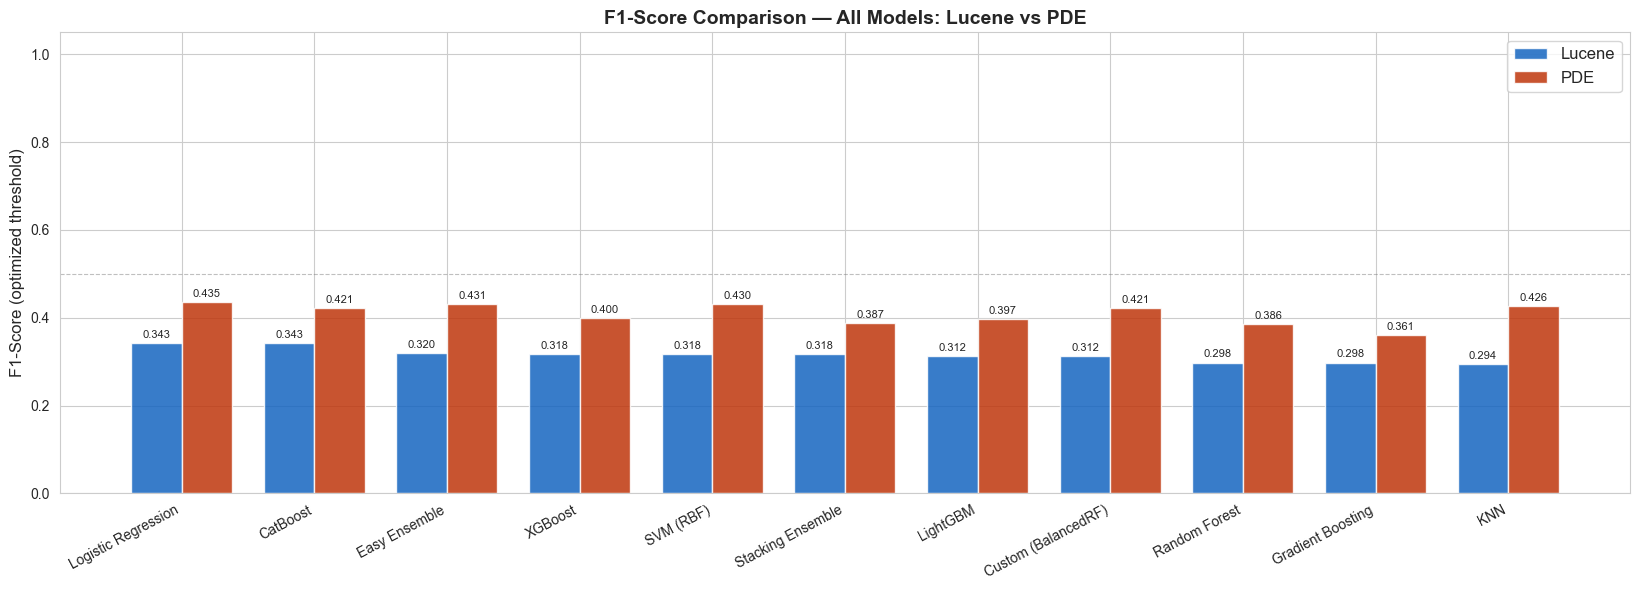

In [38]:
plot_final_comparison(eval_luc, eval_pde)


In [39]:
print('=== Threshold Optimization Summary ===')
thresh_summary = thresh_luc.rename(columns={'Best_Threshold': 'Thresh_Luc', 'Best_F1': 'F1_Luc'}).merge(
    thresh_pde.rename(columns={'Best_Threshold': 'Thresh_PDE', 'Best_F1': 'F1_PDE'}),
    on='Model', how='outer')
display(thresh_summary)
thresh_summary.to_csv(OUTPUT_DIR / 'threshold_summary.csv', index=False)


=== Threshold Optimization Summary ===


,Model,Thresh_Luc,F1_Luc,Thresh_PDE,F1_PDE
0,CatBoost,0.68,0.3429,0.54,0.4211
1,Custom (BalancedRF),0.40,0.3125,0.74,0.4211
2,Easy Ensemble,0.58,0.3200,0.56,0.4310
3,Gradient Boosting,0.10,0.2979,0.50,0.3613
4,KNN,0.18,0.2941,0.30,0.4259
5,LightGBM,0.50,0.3125,0.58,0.3967
6,Logistic Regression,0.62,0.3429,0.56,0.4348
7,Random Forest,0.10,0.2979,0.50,0.3855
8,SVM (RBF),0.78,0.3175,0.52,0.4302
9,Stacking Ensemble,0.48,0.3175,0.66,0.3871


In [40]:
print('=== CV Baseline Summary ===')
cv_summary = cv_df_luc.rename(
    columns={'CV_F1_Mean': 'CV_F1_Luc', 'CV_F1_Std': 'CV_F1Std_Luc',
             'CV_AUC_Mean': 'CV_AUC_Luc'}).merge(
    cv_df_pde.rename(
        columns={'CV_F1_Mean': 'CV_F1_PDE', 'CV_F1_Std': 'CV_F1Std_PDE',
                 'CV_AUC_Mean': 'CV_AUC_PDE'}),
    on='Model', how='outer')
display(cv_summary)
cv_summary.to_csv(OUTPUT_DIR / 'cv_baseline_summary.csv', index=False)


=== CV Baseline Summary ===


,Model,CV_F1_Luc,CV_F1Std_Luc,CV_AUC_Luc,CV_AUC_Std_x,CV_PRAUC_Mean_x,CV_MCC_Mean_x,CV_F1_PDE,CV_F1Std_PDE,CV_AUC_PDE,CV_AUC_Std_y,CV_PRAUC_Mean_y,CV_MCC_Mean_y
0,CatBoost,0.3535,0.1254,0.7417,0.1087,0.4202,0.2825,0.2766,0.0726,0.5975,0.0418,0.2956,0.1325
1,Gradient Boosting,0.3559,0.1253,0.7490,0.1051,0.4135,0.2852,0.2562,0.0339,0.5773,0.0504,0.2792,0.1100
2,KNN,0.3757,0.1494,0.7828,0.1263,0.4254,0.3774,0.3287,0.0721,0.6700,0.0493,0.3144,0.2423
3,LightGBM,0.3707,0.1192,0.7882,0.1098,0.4294,0.3041,0.2574,0.0533,0.5585,0.0501,0.2700,0.1131
4,Logistic Regression,0.4035,0.0948,0.8291,0.1163,0.4902,0.3683,0.3489,0.0535,0.7069,0.0484,0.3784,0.2217
5,Random Forest,0.3575,0.1247,0.7401,0.0964,0.3949,0.2880,0.2664,0.0675,0.6120,0.0571,0.2880,0.1247
6,SVM (RBF),0.3276,0.0936,0.8041,0.1190,0.3114,0.2949,0.3405,0.0502,0.6692,0.0606,0.2861,0.2145
7,XGBoost,0.3546,0.1379,0.7838,0.1225,0.4270,0.2859,0.2570,0.0383,0.5895,0.0642,0.2784,0.1063


In [41]:
import pickle

for mname, model in fitted_models_luc.items():
    fname = MODEL_DIR / f'lucene_{mname.lower().replace(" ", "_")}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model, f)

for mname, model in fitted_models_pde.items():
    fname = MODEL_DIR / f'pde_{mname.lower().replace(" ", "_")}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(model, f)

# Save preprocessing pipelines
with open(MODEL_DIR / 'preproc_lucene.pkl', 'wb') as f:
    pickle.dump(preproc_luc, f)
with open(MODEL_DIR / 'preproc_pde.pkl', 'wb') as f:
    pickle.dump(preproc_pde, f)

print('All models and pipelines saved to outputs/models/')
print('\nOutputs written:')
for p in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f'  {p.name}')


All models and pipelines saved to outputs/models/

Outputs written:
  cv_baseline_summary.csv
  eval_lucene.csv
  eval_pde.csv
  final_summary.csv
  mcnemar_lucene.csv
  mcnemar_pde.csv
  threshold_summary.csv
  wilcoxon_lucene.csv
  wilcoxon_pde.csv
